# s02b — MAUP: join espacial y correlación a tres escalas
## CM0866 · Análisis Exploratorio de Datos Espaciales · EAFIT 2026

---

### Objetivo

Demostrar empíricamente el **Problema de la Unidad Espacial Modificable (MAUP)** usando datos reales de Medellín a tres escalas de análisis:

| Escala | Unidad | Fuente | N aprox. |
|---|---|---|---|
| Micro | Manzana | DANE CENSO 2018 | ~200.000 |
| Meso | TAZ (Zona de Análisis de Tránsito) | EOD-AMVA 2017 | ~650 |
| Macro | Comuna | Municipio de Medellín | 16 |

**Estructura del notebook:**
1. Cargar y preparar las tres capas
2. Join espacial: manzanas → TAZ
3. Join espacial: manzanas → Comunas
4. Agregar variables por TAZ y por comuna
5. Calcular la correlación a las tres escalas
6. El MAUP en los datos: comparar resultados

### Archivos de entrada
```
manzanas_medellin_dane_2018_32618.shp   → manzanas (EPSG:32618)
EOD_2017_SIT_only_AMVA.shp             → zonas TAZ EOD 2017 (EPSG:4326 → requiere reproyección)
MDE_comunas.shp                         → comunas de Medellín (EPSG:32618)
```

### Concepto clave — el sesgo de agregación

Modelo individual: `yᵢ = α + βxᵢ + εᵢ`

Modelo agregado:   `ȳₖ = α + βx̄ₖ + ε̄ₖ + B`

donde **B = sesgo de agregación**, que depende de la covarianza entre `xᵢ` y la varianza intra-zona.
Si las zonas son internamente homogéneas en x → B ≈ 0. Si son heterogéneas → B puede ser grande y cambiar de signo.

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 0 — Configuración
# ─────────────────────────────────────────────────────────────────────────────

CRS = 32618   # UTM Zona 18N / WGS84 — metros

RUTA_MANZANAS  = '../datos/morfologia/manzanas_medellin_dane_2018.zip'
RUTA_TAZ       = '../datos/morfologia/EOD_2017_SIT_only_AMVA.zip'
RUTA_COMUNAS   = '../datos/morfologia/MDE_Comunas.zip'
RUTA_OUTPUTS   = 'outputs/'

# Variables para el análisis MAUP
# Ajustar según los campos disponibles en las manzanas
# Ejemplos típicos del DANE 2018: 'NPERSONA', 'NHOGAR', 'ESTRATO', 'VIV_OCUP'
VAR_X = None   # se detecta automáticamente en Celda 3
VAR_Y = None   # se detecta automáticamente en Celda 3

import os
os.makedirs(RUTA_OUTPUTS, exist_ok=True)
print('✓ Configuración lista')
print(f'  CRS de análisis: EPSG:{CRS}')

✓ Configuración lista
  CRS de análisis: EPSG:32618


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 1 — Importar librerías
# ─────────────────────────────────────────────────────────────────────────────

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import contextily as ctx
import warnings
warnings.filterwarnings('ignore')

print(f'GeoPandas: {gpd.__version__}')
print('✓ Librerías importadas')

GeoPandas: 1.0.1
✓ Librerías importadas


---
## Parte 1 — Cargar y preparar las tres capas

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 2 — Cargar capas y verificar CRS
# ─────────────────────────────────────────────────────────────────────────────

print('Cargando capas...')
print()

# Manzanas — ya en EPSG:32618
manzanas = gpd.read_file(RUTA_MANZANAS)
print(f'Manzanas DANE 2018:')
print(f'  Entidades: {len(manzanas):>8,}  |  CRS: EPSG:{manzanas.crs.to_epsg()}')
if manzanas.crs.to_epsg() != CRS:
    manzanas = manzanas.to_crs(epsg=CRS)
    print(f'  → Reproyectado a EPSG:{CRS} ✓')

# TAZ — viene en EPSG:4326, hay que reproyectar
taz = gpd.read_file(RUTA_TAZ)
print(f'\nZonas TAZ (EOD 2017):')
print(f'  Entidades: {len(taz):>8,}  |  CRS original: EPSG:{taz.crs.to_epsg()}')
if taz.crs.to_epsg() != CRS:
    taz = taz.to_crs(epsg=CRS)
    print(f'  → Reproyectado a EPSG:{CRS} ✓')

# Comunas — ya en EPSG:32618
comunas = gpd.read_file(RUTA_COMUNAS)
print(f'\nComunas de Medellín:')
print(f'  Entidades: {len(comunas):>8,}  |  CRS: EPSG:{comunas.crs.to_epsg()}')
if comunas.crs.to_epsg() != CRS:
    comunas = comunas.to_crs(epsg=CRS)
    print(f'  → Reproyectado a EPSG:{CRS} ✓')

print()
print('✓ Todas las capas en EPSG:', CRS)

Cargando capas...

Manzanas DANE 2018:
  Entidades:   22,008  |  CRS: EPSG:4326
  → Reproyectado a EPSG:32618 ✓

Zonas TAZ (EOD 2017):
  Entidades:      513  |  CRS original: EPSG:4326
  → Reproyectado a EPSG:32618 ✓

Comunas de Medellín:
  Entidades:       16  |  CRS: EPSG:32618

✓ Todas las capas en EPSG: 32618


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 3 — Explorar campos disponibles y elegir variables para el MAUP
# ─────────────────────────────────────────────────────────────────────────────

print('─── Campos disponibles en las manzanas ───')
print(list(manzanas.columns))
print()

# Detectar columnas numéricas (candidatas a variables del MAUP)
cols_numericas = manzanas.select_dtypes(include='number').columns.tolist()
cols_numericas = [c for c in cols_numericas if c not in ['geometry']]

print('Columnas numéricas disponibles:')
for col in cols_numericas:
    no_nulos = manzanas[col].notna().sum()
    pct = no_nulos / len(manzanas) * 100
    print(f'  {col:<25} min={manzanas[col].min():.1f}  max={manzanas[col].max():.1f}  '
          f'media={manzanas[col].mean():.1f}  completitud={pct:.0f}%')

print()
print('─── Instrucción ───')
print('Elige dos variables numéricas para el análisis MAUP.')
print('Actualiza VAR_X y VAR_Y en la celda de abajo.')

─── Campos disponibles en las manzanas ───
['COD_DANE_A', 'DPTO_CCDGO', 'MPIO_CCDGO', 'MPIO_CDPMP', 'CLAS_CCDGO', 'SETR_CCDGO', 'SETR_CCNCT', 'SECR_CCDGO', 'SECR_CCNCT', 'ZU_CCDGO', 'ZU_CDIVI', 'SETU_CCDGO', 'SETU_CCNCT', 'SECU_CCDGO', 'SECU_CCNCT', 'MANZ_CCDGO', 'AG_CCDGO', 'DATO_ANM', 'VERSION', 'AREA', 'LATITUD', 'LONGITUD', 'DENSIDAD', 'CTNENCUEST', 'TP3_1_SI', 'TP3_2_NO', 'TP3A_RI', 'TP3B_TCN', 'TP4_1_SI', 'TP4_2_NO', 'TP9_1_USO', 'TP9_2_USO', 'TP9_3_USO', 'TP9_4_USO', 'TP9_2_1_MI', 'TP9_2_2_MI', 'TP9_2_3_MI', 'TP9_2_4_MI', 'TP9_2_9_MI', 'TP9_3_1_NO', 'TP9_3_2_NO', 'TP9_3_3_NO', 'TP9_3_4_NO', 'TP9_3_5_NO', 'TP9_3_6_NO', 'TP9_3_7_NO', 'TP9_3_8_NO', 'TP9_3_9_NO', 'TP9_3_10_N', 'TP9_3_99_N', 'TVIVIENDA', 'TP14_1_TIP', 'TP14_2_TIP', 'TP14_3_TIP', 'TP14_4_TIP', 'TP14_5_TIP', 'TP14_6_TIP', 'TP15_1_OCU', 'TP15_2_OCU', 'TP15_3_OCU', 'TP15_4_OCU', 'TP16_HOG', 'TP19_EE_1', 'TP19_EE_2', 'TP19_EE_E1', 'TP19_EE_E2', 'TP19_EE_E3', 'TP19_EE_E4', 'TP19_EE_E5', 'TP19_EE_E6', 'TP19_EE_E9', 'TP19_AC

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 4 — Construir variables derivadas y seleccionar para el MAUP
# ─────────────────────────────────────────────────────────────────────────────

# ── Variable 1: Estrato socioeconómico promedio ponderado por viviendas ──────
# Suma ponderada: (1×E1 + 2×E2 + ... + 6×E6) / total de viviendas
# Resultado: número continuo entre 1 y 6

cols_estrato = ['TP19_EE_E1','TP19_EE_E2','TP19_EE_E3',
                'TP19_EE_E4','TP19_EE_E5','TP19_EE_E6']

# Total de viviendas con estrato conocido por manzana
manzanas['total_viv_estrato'] = manzanas[cols_estrato].sum(axis=1)

# Estrato promedio ponderado
manzanas['estrato_promedio'] = (
    manzanas['TP19_EE_E1'] * 1 +
    manzanas['TP19_EE_E2'] * 2 +
    manzanas['TP19_EE_E3'] * 3 +
    manzanas['TP19_EE_E4'] * 4 +
    manzanas['TP19_EE_E5'] * 5 +
    manzanas['TP19_EE_E6'] * 6
) / manzanas['total_viv_estrato'].replace(0, np.nan)

# ── Variable 2: Proporción de viviendas de estrato bajo (E1 + E2) ────────────
# Resultado: 0.0 a 1.0 — fracción de viviendas en estrato 1 o 2

manzanas['prop_estrato_bajo'] = (
    manzanas['TP19_EE_E1'] + manzanas['TP19_EE_E2']
) / manzanas['total_viv_estrato'].replace(0, np.nan)

# ── Variable 3: Densidad de personas por vivienda ────────────────────────────
# Personas / total de viviendas con estrato conocido

manzanas['dens_personas_viv'] = (
    manzanas['TP27_PERSO'] /
    manzanas['total_viv_estrato'].replace(0, np.nan)
)

# ── Verificación ─────────────────────────────────────────────────────────────
print('─── Variables construidas ───')
print()
for col in ['estrato_promedio', 'prop_estrato_bajo', 'dens_personas_viv']:
    serie = manzanas[col].dropna()
    print(f'{col}:')
    print(f'  min={serie.min():.3f}  media={serie.mean():.3f}  '
          f'max={serie.max():.3f}  N válidos={len(serie):,}')
    print()

# ── Selección de variables para el MAUP ──────────────────────────────────────
# Opción A — más directa pedagógicamente:
# ¿Las manzanas con más estrato tienen menos personas por vivienda?
VAR_X = 'estrato_promedio'
VAR_Y = 'TP27_PERSO'

# Opción B — más interesante geográficamente:
# ¿Las manzanas con más estrato bajo tienen más densidad de personas?
# VAR_X = 'prop_estrato_bajo'
# VAR_Y = 'dens_personas_viv'

# Opción C — para mostrar segregación:
# ¿Las manzanas con más personas tienen estrato más bajo?
# VAR_X = 'TP27_PERSO'
# VAR_Y = 'estrato_promedio'

print(f'Variables seleccionadas para el análisis MAUP:')
print(f'  VAR_X = "{VAR_X}"')
print(f'  VAR_Y = "{VAR_Y}"')
print()

# Filtrar manzanas sin datos en ambas variables
manzanas_ok = manzanas[[VAR_X, VAR_Y, 'geometry'] +
                         cols_estrato + ['total_viv_estrato']].dropna(
                             subset=[VAR_X, VAR_Y])

print(f'Manzanas con ambas variables completas: {len(manzanas_ok):,}')
print(f'Manzanas sin datos (excluidas):         {len(manzanas)-len(manzanas_ok):,}')
print()

# Nota sobre manzanas sin estrato
sin_viv = (manzanas['total_viv_estrato'] == 0).sum()
print(f'Manzanas sin ninguna vivienda con estrato: {sin_viv:,}')
print('(Pueden ser manzanas industriales, viales o de uso institucional)')

─── Variables construidas ───

estrato_promedio:
  min=1.000  media=2.389  max=6.000  N válidos=19,044

prop_estrato_bajo:
  min=0.000  media=0.605  max=1.000  N válidos=19,044

dens_personas_viv:
  min=1.000  media=3.191  max=121.000  N válidos=19,044

Variables seleccionadas para el análisis MAUP:
  VAR_X = "estrato_promedio"
  VAR_Y = "TP27_PERSO"

Manzanas con ambas variables completas: 19,044
Manzanas sin datos (excluidas):         2,964

Manzanas sin ninguna vivienda con estrato: 2,964
(Pueden ser manzanas industriales, viales o de uso institucional)


---
## Parte 2 — Join espacial: manzanas → TAZ

Asignamos a cada manzana el código de la TAZ que la contiene.

**Predicado:** `within` — la manzana está completamente dentro de la TAZ.

**Atención MAUP:** las TAZ vienen de la EOD-AMVA 2017. Sus límites fueron diseñados para modelación de transporte, no para análisis censal. Algunas TAZ pueden cruzar límites de comunas. Eso es exactamente el efecto de zonificación del MAUP.

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 5 — Join espacial: manzanas → TAZ
# ─────────────────────────────────────────────────────────────────────────────

print('Join espacial: manzanas → TAZ (predicate=within)...')

# Identificar columna ID de las TAZ
print(f'Columnas TAZ: {list(taz.columns)}')
col_id_taz = next(
    (c for c in ['TAZ_ID','taz_id','ZAT','ID','id','COD_ZAT','ZONA'] if c in taz.columns),
    taz.columns[0]
)
print(f'Usando como ID de TAZ: "{col_id_taz}"')
print()

# Join
manz_taz = gpd.sjoin(
    manzanas[['geometry', VAR_X, VAR_Y]].reset_index(names='manz_id'),
    taz[[col_id_taz, 'geometry']].rename(columns={col_id_taz: 'id_taz'}),
    how='left',
    predicate='within'
)

# Verificaciones post-join
print('─── Verificaciones post-join ───')
print(f'  Filas esperadas:   {len(manzanas):>8,}')
print(f'  Filas resultado:   {len(manz_taz):>8,}')

if len(manz_taz) > len(manzanas):
    duplicados = len(manz_taz) - len(manzanas)
    print(f'  ⚠  {duplicados:,} filas extra — manzanas en el borde entre dos TAZ')
    # Quedarse con la primera asignación
    manz_taz = manz_taz.loc[~manz_taz['manz_id'].duplicated(keep='first')]
    print(f'  → Eliminados duplicados. Filas finales: {len(manz_taz):,}')

sin_taz = manz_taz['id_taz'].isna().sum()
print(f'\n  Manzanas sin TAZ asignada: {sin_taz:,} ({sin_taz/len(manz_taz)*100:.1f}%)')
if sin_taz > 0:
    print('  Razón: manzanas fuera del área de cobertura de la EOD-AMVA (municipios no incluidos)')

taz_por_manzana = manz_taz['id_taz'].nunique()
print(f'\n  TAZ distintas asignadas: {taz_por_manzana}')
print(f'  TAZ totales disponibles: {taz[col_id_taz].nunique()}')
print(f'  Manzanas por TAZ (media): {(~manz_taz.id_taz.isna()).sum()/taz_por_manzana:.0f}')

Join espacial: manzanas → TAZ (predicate=within)...
Columnas TAZ: ['SIT_2017', 'fuente', 'geometry']
Usando como ID de TAZ: "SIT_2017"

─── Verificaciones post-join ───
  Filas esperadas:     22,008
  Filas resultado:     22,008

  Manzanas sin TAZ asignada: 3,135 (14.2%)
  Razón: manzanas fuera del área de cobertura de la EOD-AMVA (municipios no incluidos)

  TAZ distintas asignadas: 486
  TAZ totales disponibles: 513
  Manzanas por TAZ (media): 39


---
## Parte 3 — Join espacial: manzanas → Comunas

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 6 — Join espacial: manzanas → Comunas
# ─────────────────────────────────────────────────────────────────────────────

print('Join espacial: manzanas → Comunas (predicate=within)...')

print(f'Columnas comunas: {list(comunas.columns)}')
col_id_comuna = next(
    (c for c in ['CODIGO','codigo','COD_COMUNA','id_comuna','COMUNAS','NOM_COMUNI','NOMBRE'] 
     if c in comunas.columns),
    comunas.columns[0]
)
print(f'Usando como ID de comuna: "{col_id_comuna}"')
print()

manz_com = gpd.sjoin(
    manzanas[['geometry', VAR_X, VAR_Y]].reset_index(names='manz_id'),
    comunas[[col_id_comuna, 'geometry']].rename(columns={col_id_comuna: 'id_comuna'}),
    how='left',
    predicate='within'
)

print('─── Verificaciones post-join ───')
print(f'  Filas esperadas:   {len(manzanas):>8,}')
print(f'  Filas resultado:   {len(manz_com):>8,}')

if len(manz_com) > len(manzanas):
    manz_com = manz_com.loc[~manz_com['manz_id'].duplicated(keep='first')]
    print(f'  → Duplicados eliminados. Filas finales: {len(manz_com):,}')

sin_comuna = manz_com['id_comuna'].isna().sum()
print(f'\n  Manzanas sin comuna asignada: {sin_comuna:,} ({sin_comuna/len(manz_com)*100:.1f}%)')

print(f'\n  Comunas distintas asignadas: {manz_com["id_comuna"].nunique()}')
print(f'  Manzanas por comuna (media): {(~manz_com.id_comuna.isna()).sum()/manz_com["id_comuna"].nunique():.0f}')

# Distribución de manzanas por comuna
print(f'\n  Distribución de manzanas por comuna:')
dist_comunas = manz_com.groupby('id_comuna').size().describe()
print(f'    min={dist_comunas["min"]:.0f}  mediana={dist_comunas["50%"]:.0f}  '
      f'media={dist_comunas["mean"]:.0f}  max={dist_comunas["max"]:.0f}')

Join espacial: manzanas → Comunas (predicate=within)...
Columnas comunas: ['CODIGO', 'NOMBRE', 'IDENTIFICA', 'LIMITEMUNI', 'Shape_Leng', 'Area_km2', 'geometry']
Usando como ID de comuna: "CODIGO"

─── Verificaciones post-join ───
  Filas esperadas:     22,008
  Filas resultado:     22,008

  Manzanas sin comuna asignada: 10,079 (45.8%)

  Comunas distintas asignadas: 16
  Manzanas por comuna (media): 746

  Distribución de manzanas por comuna:
    min=412  mediana=755  media=746  max=1089


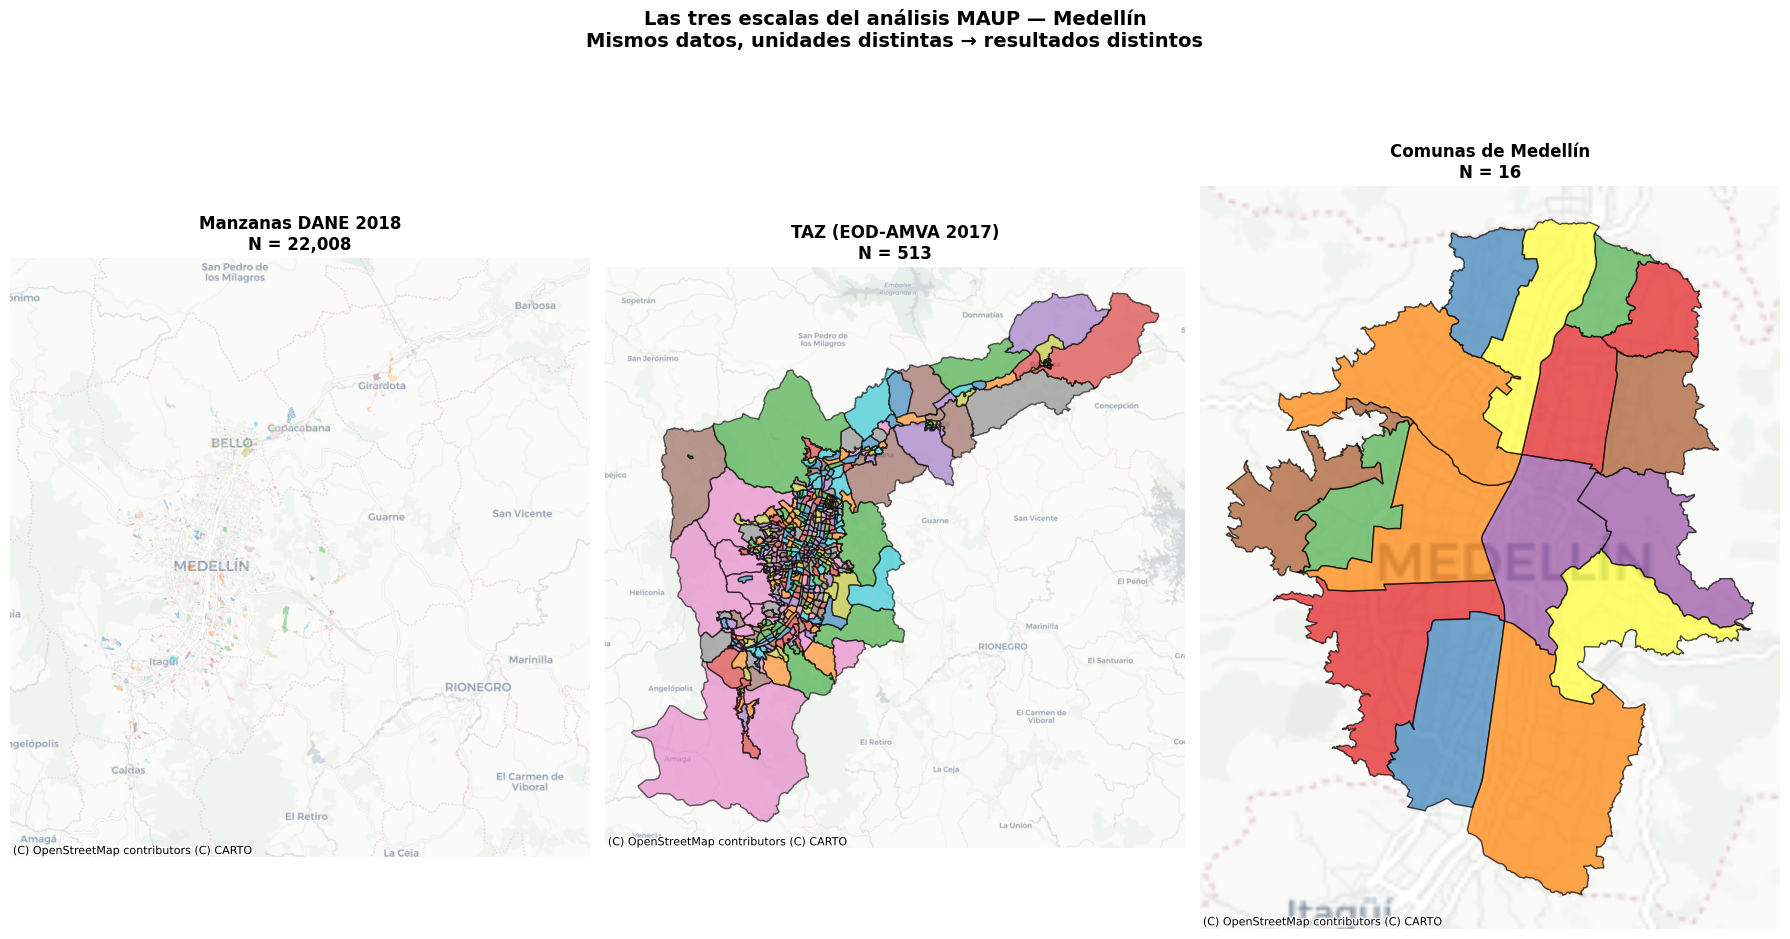

✓ Mapa guardado: outputs/s02b_tres_escalas.png


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 7 — Mapa de los tres niveles de zonificación
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 10))

# Colorear cada zona aleatoriamente para mostrar los límites
import random
random.seed(42)

capas_info = [
    (manzanas.sample(min(5000, len(manzanas))), 'Manzanas DANE 2018',
     f'N = {len(manzanas):,}', 0.4),
    (taz, f'TAZ (EOD-AMVA 2017)',
     f'N = {len(taz):,}', 0.6),
    (comunas, 'Comunas de Medellín',
     f'N = {len(comunas)}', 0.7),
]

colormaps = ['tab20', 'tab10', 'Set1']

for i, (capa, titulo, subtitulo, alpha) in enumerate(capas_info):
    ax = axes[i]
    capa.to_crs(epsg=3857).plot(
        ax=ax,
        color=[plt.cm.get_cmap(colormaps[i])(j % 20 / 20)
               for j in range(len(capa))],
        alpha=alpha,
        linewidth=0.3 if i == 0 else 1.0,
        edgecolor='white' if i == 0 else 'black'
    )
    try:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=11)
    except:
        pass
    ax.set_title(f'{titulo}\n{subtitulo}', fontsize=12, fontweight='bold')
    ax.set_axis_off()

plt.suptitle(
    f'Las tres escalas del análisis MAUP — Medellín\n'
    f'Mismos datos, unidades distintas → resultados distintos',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()

ruta_mapa_escalas = f'{RUTA_OUTPUTS}s02b_tres_escalas.png'
plt.savefig(ruta_mapa_escalas, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Mapa guardado: {ruta_mapa_escalas}')

---
## Parte 4 — Agregar variables por TAZ y por comuna

Calculamos los promedios de VAR_X y VAR_Y para cada zona usando la media simple.  
En el análisis MAUP, este es el paso donde el sesgo de agregación B se introduce.

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 8 — Agregar variables por TAZ y por comuna
# ─────────────────────────────────────────────────────────────────────────────

print('Agregando variables...')
print()

# ── Por TAZ ──────────────────────────────────────────────────────────────────
resumen_taz = (
    manz_taz.dropna(subset=['id_taz', VAR_X, VAR_Y])
    .groupby('id_taz')
    .agg(
        n_manzanas=(VAR_X, 'count'),
        x_media=(VAR_X, 'mean'),
        y_media=(VAR_Y, 'mean'),
        x_std=(VAR_X, 'std'),
        y_std=(VAR_Y, 'std'),
    )
    .reset_index()
)

# ── Por comuna ────────────────────────────────────────────────────────────────
resumen_comuna = (
    manz_com.dropna(subset=['id_comuna', VAR_X, VAR_Y])
    .groupby('id_comuna')
    .agg(
        n_manzanas=(VAR_X, 'count'),
        x_media=(VAR_X, 'mean'),
        y_media=(VAR_Y, 'mean'),
        x_std=(VAR_X, 'std'),
        y_std=(VAR_Y, 'std'),
    )
    .reset_index()
)

print('─── Resumen por TAZ ───')
print(f'  TAZ con datos: {len(resumen_taz)}')
print(f'  Manzanas por TAZ: media={resumen_taz.n_manzanas.mean():.0f}  '
      f'min={resumen_taz.n_manzanas.min()}  max={resumen_taz.n_manzanas.max()}')
print(f'  Heterogeneidad interna ({VAR_X}) — std medio: {resumen_taz.x_std.mean():.2f}')
print()
print('─── Resumen por commune ───')
print(f'  Comunas con datos: {len(resumen_comuna)}')
print(f'  Manzanas por comuna: media={resumen_comuna.n_manzanas.mean():.0f}  '
      f'min={resumen_comuna.n_manzanas.min()}  max={resumen_comuna.n_manzanas.max()}')
print(f'  Heterogeneidad interna ({VAR_X}) — std medio: {resumen_comuna.x_std.mean():.2f}')
print()
print('Nota: a medida que la zona es más grande, la heterogeneidad interna')
print('(std) aumenta — más varianza se pierde al agregar.')

Agregando variables...

─── Resumen por TAZ ───
  TAZ con datos: 473
  Manzanas por TAZ: media=35  min=1  max=251
  Heterogeneidad interna (estrato_promedio) — std medio: 0.36

─── Resumen por commune ───
  Comunas con datos: 16
  Manzanas por comuna: media=649  min=297  max=981
  Heterogeneidad interna (estrato_promedio) — std medio: 0.66

Nota: a medida que la zona es más grande, la heterogeneidad interna
(std) aumenta — más varianza se pierde al agregar.


---
## Parte 5 — El MAUP: correlación a las tres escalas

Esta es la demostración central. Calculamos la correlación de Pearson entre VAR_X y VAR_Y a tres niveles de agregación y comparamos los resultados.

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 9 — Correlación a las tres escalas
# ─────────────────────────────────────────────────────────────────────────────

manzanas_ok = manzanas[[VAR_X, VAR_Y]].dropna()

# Escala 1: MANZANA
r_manzana = manzanas_ok[VAR_X].corr(manzanas_ok[VAR_Y])
n_manzana = len(manzanas_ok)

# Escala 2: TAZ
r_taz = resumen_taz['x_media'].corr(resumen_taz['y_media'])
n_taz = len(resumen_taz)

# Escala 3: COMUNA
r_comuna = resumen_comuna['x_media'].corr(resumen_comuna['y_media'])
n_comuna = len(resumen_comuna)

print('═' * 55)
print('  MAUP — Correlación a las tres escalas')
print(f'  Variables: {VAR_X} vs. {VAR_Y}')
print('═' * 55)
print()
print(f'  Escala MANZANA   N={n_manzana:>8,}   r = {r_manzana:+.4f}')
print(f'  Escala TAZ       N={n_taz:>8,}   r = {r_taz:+.4f}')
print(f'  Escala COMUNA    N={n_comuna:>8,}   r = {r_comuna:+.4f}')
print()

# Diagnóstico automático
cambios = []
if r_manzana * r_taz < 0:
    cambios.append(('MANZANA', 'TAZ', r_manzana, r_taz))
if r_taz * r_comuna < 0:
    cambios.append(('TAZ', 'COMUNA', r_taz, r_comuna))
if r_manzana * r_comuna < 0:
    cambios.append(('MANZANA', 'COMUNA', r_manzana, r_comuna))

if cambios:
    print('  ⚠  MAUP DRAMÁTICO: LA CORRELACIÓN CAMBIÓ DE SIGNO')
    for e1, e2, r1, r2 in cambios:
        print(f'     {e1} (r={r1:+.3f}) → {e2} (r={r2:+.3f})')
    print('  Esto significa que la relación cambia de dirección al cambiar la escala.')
    print('  El fenómeno opera de forma distinta a nivel de manzana que a nivel de zona.')
else:
    delta_max = max(abs(r_taz-r_manzana), abs(r_comuna-r_manzana), abs(r_comuna-r_taz))
    if delta_max > 0.2:
        print(f'  ⚠  EFECTO DE ESCALA SUSTANCIAL: variación máxima = {delta_max:.3f}')
        print('  La magnitud de la correlación cambia significativamente entre escalas.')
    else:
        print(f'  ✓  Resultado relativamente robusto: variación máxima = {delta_max:.3f}')
        print('  Las conclusiones principales no cambian entre escalas.')

print()
print('─── Pregunta clave ───')
print(f'¿A qué escala opera realmente la relación entre {VAR_X} y {VAR_Y}?')
print('¿Cuál resultado es el más relevante para tu pregunta de investigación?')

═══════════════════════════════════════════════════════
  MAUP — Correlación a las tres escalas
  Variables: estrato_promedio vs. TP27_PERSO
═══════════════════════════════════════════════════════

  Escala MANZANA   N=  19,044   r = +0.1805
  Escala TAZ       N=     473   r = +0.3475
  Escala COMUNA    N=      16   r = +0.4738

  ⚠  EFECTO DE ESCALA SUSTANCIAL: variación máxima = 0.293
  La magnitud de la correlación cambia significativamente entre escalas.

─── Pregunta clave ───
¿A qué escala opera realmente la relación entre estrato_promedio y TP27_PERSO?
¿Cuál resultado es el más relevante para tu pregunta de investigación?


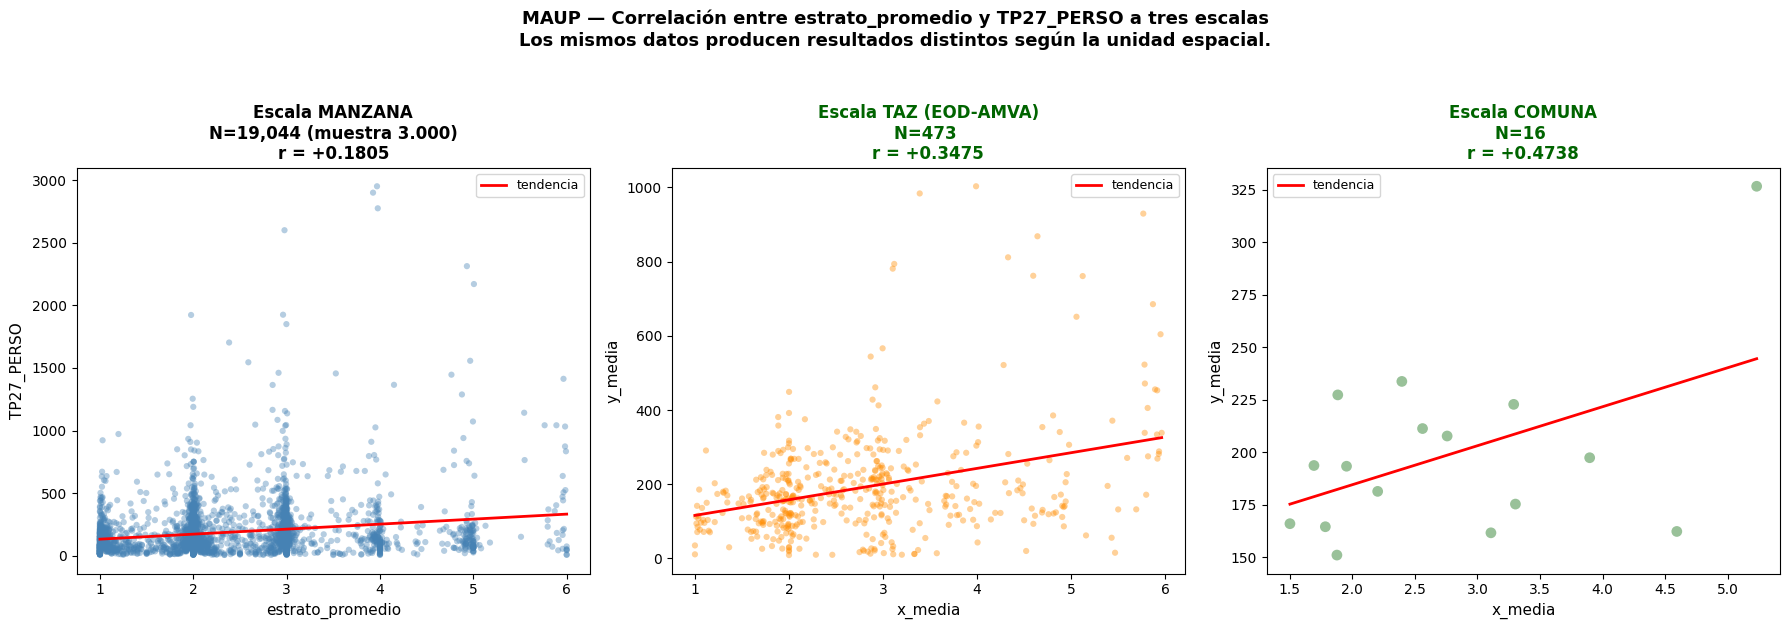

✓ Scatter plots guardados: outputs/s02b_maup_scatter.png


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 10 — Scatter plots a las tres escalas
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

escalas = [
    (manzanas_ok.sample(min(3000, len(manzanas_ok)), random_state=42),
     VAR_X, VAR_Y, r_manzana, n_manzana,
     'Escala MANZANA', 'steelblue', '(muestra 3.000)'),
    (resumen_taz, 'x_media', 'y_media', r_taz, n_taz,
     'Escala TAZ (EOD-AMVA)', 'darkorange', ''),
    (resumen_comuna, 'x_media', 'y_media', r_comuna, n_comuna,
     'Escala COMUNA', 'darkgreen', ''),
]

for ax, (df, x, y, r, n, titulo, color, extra) in zip(axes, escalas):
    ax.scatter(df[x], df[y], alpha=0.4, s=20 if n > 100 else 60,
               color=color, edgecolors='none')

    # Línea de tendencia
    datos_ok = df[[x, y]].dropna()
    if len(datos_ok) > 2:
        z = np.polyfit(datos_ok[x], datos_ok[y], 1)
        p = np.poly1d(z)
        x_line = np.linspace(datos_ok[x].min(), datos_ok[x].max(), 100)
        ax.plot(x_line, p(x_line), color='red', lw=2, label=f'tendencia')

    ax.set_xlabel(f'{x}', fontsize=11)
    ax.set_ylabel(f'{y}', fontsize=11)
    titulo_color = 'darkred' if r < 0 else 'darkgreen'
    ax.set_title(
        f'{titulo}\nN={n:,} {extra}\nr = {r:+.4f}',
        fontsize=12, fontweight='bold',
        color=titulo_color if abs(r) > 0.3 else 'black'
    )
    ax.legend(fontsize=9)

plt.suptitle(
    f'MAUP — Correlación entre {VAR_X} y {VAR_Y} a tres escalas\n'
    f'Los mismos datos producen resultados distintos según la unidad espacial.',
    fontsize=13, fontweight='bold', y=1.04
)
plt.tight_layout()

ruta_scatter = f'{RUTA_OUTPUTS}s02b_maup_scatter.png'
plt.savefig(ruta_scatter, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Scatter plots guardados: {ruta_scatter}')

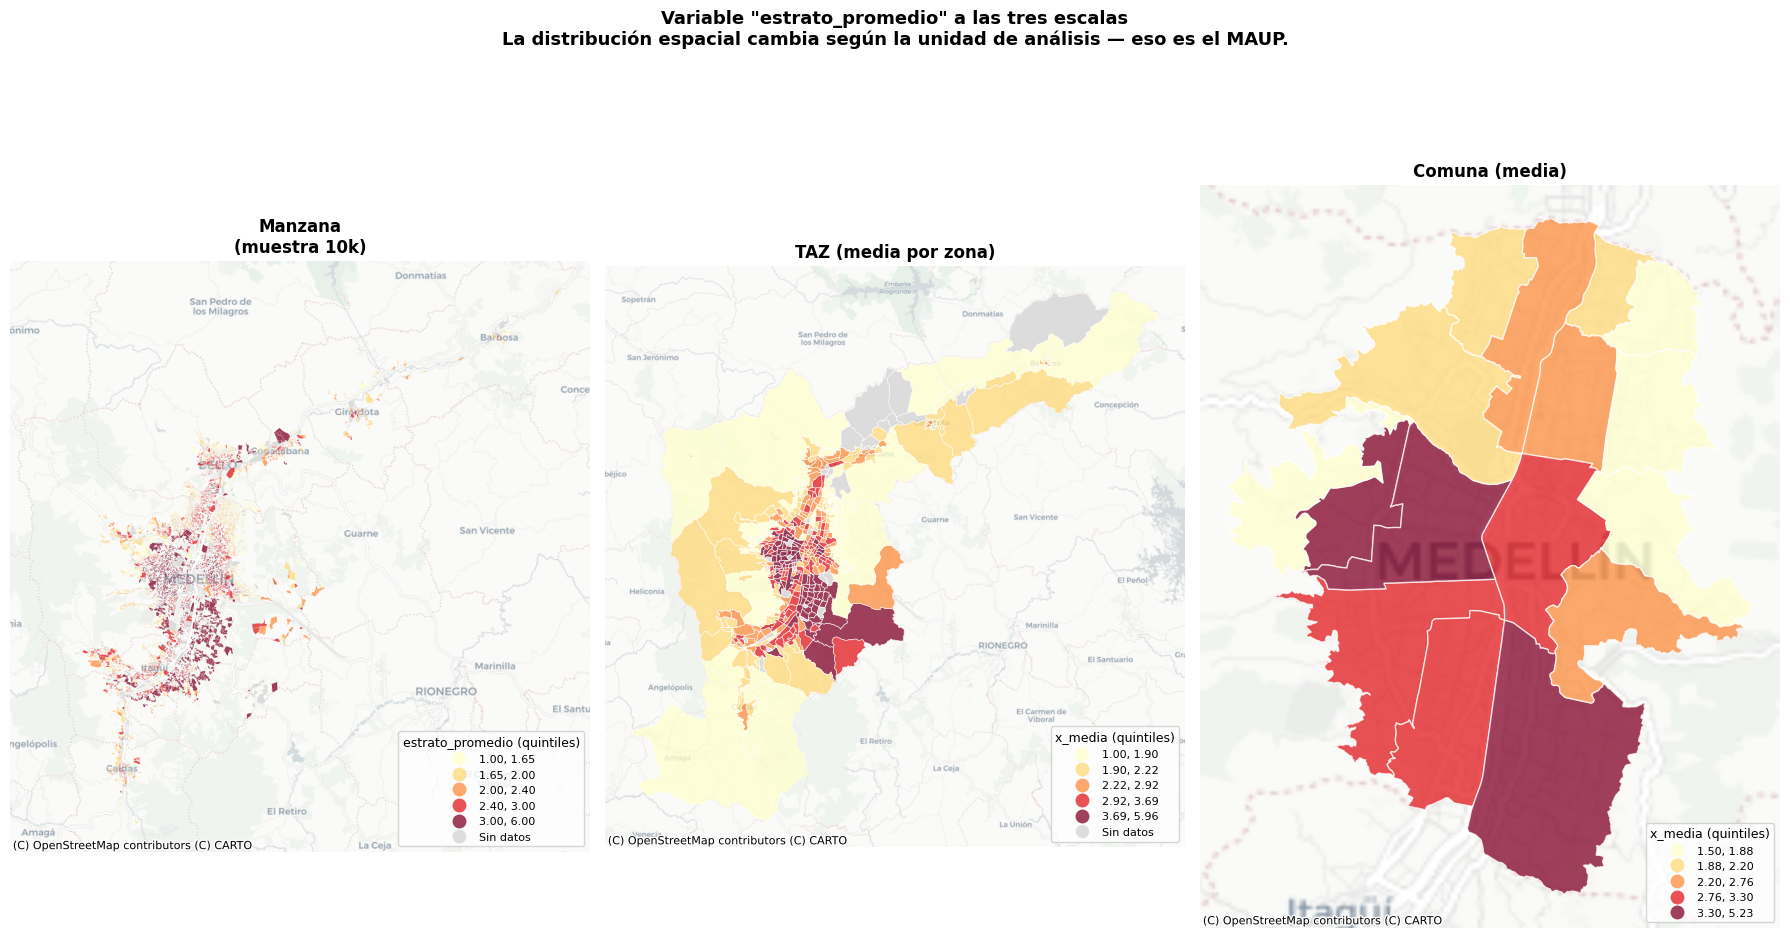

✓ Mapas MAUP guardados: outputs/s02b_maup_mapas.png


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 11 — Mapa de la variable por las tres escalas
# ─────────────────────────────────────────────────────────────────────────────

# Unir promedios a las capas geográficas
taz_plot = taz.merge(
    resumen_taz[['id_taz','x_media','y_media']],
    left_on=col_id_taz, right_on='id_taz', how='left'
).to_crs(epsg=3857)

comunas_plot = comunas.merge(
    resumen_comuna[['id_comuna','x_media','y_media']],
    left_on=col_id_comuna, right_on='id_comuna', how='left'
).to_crs(epsg=3857)

manzanas_muestra = manzanas.sample(min(10000, len(manzanas)), random_state=42).to_crs(epsg=3857)

fig, axes = plt.subplots(1, 3, figsize=(18, 10))

capas_mapa = [
    (manzanas_muestra, VAR_X, 'Manzana\n(muestra 10k)', 0.05),
    (taz_plot, 'x_media', 'TAZ (media por zona)', 0.5),
    (comunas_plot, 'x_media', 'Comuna (media)', 1.0),
]

for ax, (capa, col, titulo, lw) in zip(axes, capas_mapa):
    capa.plot(
        column=col,
        cmap='YlOrRd',
        scheme='quantiles', k=5,
        legend=True,
        legend_kwds={
            'title': f'{col} (quintiles)',
            'loc': 'lower right',
            'fontsize': 8,
            'title_fontsize': 9,
        },
        alpha=0.75,
        linewidth=lw,
        edgecolor='white',
        ax=ax,
        missing_kwds={'color': 'lightgrey', 'label': 'Sin datos'}
    )
    try:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=11)
    except Exception:
        pass
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_axis_off()

plt.suptitle(
    f'Variable "{VAR_X}" a las tres escalas\n'
    f'La distribución espacial cambia según la unidad de análisis — eso es el MAUP.',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()

ruta_mapa_maup = f'{RUTA_OUTPUTS}s02b_maup_mapas.png'
plt.savefig(ruta_mapa_maup, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Mapas MAUP guardados: {ruta_mapa_maup}')

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 12 — Exportar y resumen final
# ─────────────────────────────────────────────────────────────────────────────

# Exportar tablas de agregación
resumen_taz.to_csv(f'{RUTA_OUTPUTS}s02b_resumen_taz.csv', index=False)
resumen_comuna.to_csv(f'{RUTA_OUTPUTS}s02b_resumen_comunas.csv', index=False)

# Exportar la asignación manzana → zona
manz_taz[['manz_id','id_taz',VAR_X,VAR_Y]].to_csv(
    f'{RUTA_OUTPUTS}s02b_manzanas_taz.csv', index=False
)
manz_com[['manz_id','id_comuna',VAR_X,VAR_Y]].to_csv(
    f'{RUTA_OUTPUTS}s02b_manzanas_comunas.csv', index=False
)

print('═' * 60)
print('  RESUMEN FINAL — s02b MAUP')
print('═' * 60)
print()
print(f'  Variables analizadas: {VAR_X} vs. {VAR_Y}')
print()
print(f'  ┌─────────────────┬──────────┬──────────────┐')
print(f'  │ Escala          │    N     │      r       │')
print(f'  ├─────────────────┼──────────┼──────────────┤')
print(f'  │ Manzana         │ {n_manzana:>8,} │  {r_manzana:+.4f}      │')
print(f'  │ TAZ (EOD-AMVA)  │ {n_taz:>8,} │  {r_taz:+.4f}      │')
print(f'  │ Comuna          │ {n_comuna:>8,} │  {r_comuna:+.4f}      │')
print(f'  └─────────────────┴──────────┴──────────────┘')
print()

if cambios:
    print('  CONCLUSIÓN: La correlación CAMBIÓ DE SIGNO entre escalas.')
    print('  Este es el MAUP en su forma más severa.')
else:
    print(f'  CONCLUSIÓN: El signo se mantiene pero la magnitud varía.')
    print(f'  Variación máxima: {max(abs(r_taz-r_manzana), abs(r_comuna-r_manzana), abs(r_comuna-r_taz)):.3f}')
print()
print('  Archivos generados:')
for f in ['s02b_tres_escalas.png', 's02b_maup_scatter.png',
          's02b_maup_mapas.png', 's02b_resumen_taz.csv',
          's02b_resumen_comunas.csv']:
    print(f'  · {RUTA_OUTPUTS}{f}')
print('═' * 60)

════════════════════════════════════════════════════════════
  RESUMEN FINAL — s02b MAUP
════════════════════════════════════════════════════════════

  Variables analizadas: estrato_promedio vs. TP27_PERSO

  ┌─────────────────┬──────────┬──────────────┐
  │ Escala          │    N     │      r       │
  ├─────────────────┼──────────┼──────────────┤
  │ Manzana         │   19,044 │  +0.1805      │
  │ TAZ (EOD-AMVA)  │      473 │  +0.3475      │
  │ Comuna          │       16 │  +0.4738      │
  └─────────────────┴──────────┴──────────────┘

  CONCLUSIÓN: El signo se mantiene pero la magnitud varía.
  Variación máxima: 0.293

  Archivos generados:
  · outputs/s02b_tres_escalas.png
  · outputs/s02b_maup_scatter.png
  · outputs/s02b_maup_mapas.png
  · outputs/s02b_resumen_taz.csv
  · outputs/s02b_resumen_comunas.csv
════════════════════════════════════════════════════════════


---
## Preguntas para la bitácora

1. ¿La correlación cambió de signo entre alguna de las tres escalas? ¿Qué mecanismo explicaría ese cambio?

2. ¿Las TAZ de la EOD-AMVA 2017 respetan los límites de las comunas, o algunas TAZ cruzan esos límites? ¿Qué implicación tiene eso para comparar resultados entre las dos escalas?

3. Observa el mapa de la variable a las tres escalas. ¿Qué patrones espaciales son visibles a nivel de manzana que desaparecen al agregar a TAZ o comuna?

4. Para el proyecto integrador: ¿cuál de las tres escalas usarías como unidad de análisis? Justifica en dos oraciones considerando (a) el fenómeno que estudias y (b) el resultado del análisis de sensibilidad que acabas de hacer.

5. El sesgo de agregación B = ȳₖ − (α + βx̄ₖ) depende de la heterogeneidad interna de las zonas. ¿Las comunas de Medellín son internamente homogéneas en la variable que analizaste? ¿Cómo lo verificarías?

---
*CM0866 · Juan Pablo Ospina Zapata · EAFIT 2026*